# PubMedQA Classification with Unsloth QLoRA (Qwen2.5 7B)

This is the **Unsloth version** of the original PubMedQA fine-tuning notebook.

Goal: keep the same dataset, prompts, split, LoRA capacity, validation logic, and metrics as much as possible, while replacing the standard `transformers + bitsandbytes + peft` QLoRA model setup with **Unsloth's optimized `FastLanguageModel` path**.

## What changed vs the original notebook

- Replaces `AutoModelForCausalLM + BitsAndBytesConfig + prepare_model_for_kbit_training + get_peft_model`
  with `FastLanguageModel.from_pretrained(...)` and `FastLanguageModel.get_peft_model(...)`.
- Uses an Unsloth 4-bit Qwen checkpoint: `unsloth/Qwen2.5-7B-Instruct-bnb-4bit`.
- Uses Unsloth gradient checkpointing: `use_gradient_checkpointing="unsloth"`.
- Keeps PubMedQA preprocessing, class balancing, dual-format supervision, score-based classification, and final metrics.
- Adds runtime and peak GPU memory logging so you can compare with the non-Unsloth notebook.

> For a fair comparison, run this notebook under the same GPU, batch size, sequence length, epochs, and dataset settings as the original notebook.


## Diagnostic Fixes Applied

I found the notebook stopped at the import/setup step because the environment tried to import a broken `wandb` package:

`ImportError: cannot import name 'Imports' from 'wandb.proto.wandb_telemetry_pb2'`

This corrected notebook:
- disables and uninstalls W&B because this run uses `report_to=[]` / no W&B logging;
- avoids separately upgrading `trl`, `transformers`, `peft`, and `bitsandbytes` after installing Unsloth, because that can break Unsloth's version compatibility;
- adds TRL compatibility logic for `SFTConfig` and `SFTTrainer` API changes;
- keeps the same notebook filename and the same PubMedQA/Unsloth training goal.


Additional fix in this version:
- Replaced the invalid notebook shell here-document with a pure Python `subprocess` install cell to fix `NameError: name 'PY' is not defined`.
- Pinned `protobuf`, `numpy`, and `scikit-learn` to avoid the dependency-conflict warnings from the failed run.
Additional fix in this version:
- Removed the explicit `numpy>=1.26,<2.2` install because it downgraded numpy after it was already loaded in memory.
- Added `datasets>=3.4.1,<4.4` because the failed run installed `datasets 5.0.0`, while Unsloth required `<4.4`.
- Kept protobuf bounded to `<6` but avoided changing numpy.

Additional fix in this version:
- Removed `NotebookProgressCallback` and set `disable_tqdm=True` because Transformers 5.x notebook progress tracking raised `RuntimeError: on_train_begin must be called before on_evaluate` during manual evaluation.
- Added a safe `trainer.evaluate()` retry that removes notebook progress callbacks if they reappear.


## 1. Install Required Dependencies

In [1]:
# Kaggle / Colab-friendly dependencies
# Fixed v3:
# - Do NOT use shell heredocs in notebook cells.
# - Do NOT pin/downgrade numpy mid-session: Unsloth detects loaded-vs-installed numpy mismatch and aborts.
# - Keep datasets compatible with the installed Unsloth requirement (<4.4), instead of upgrading to datasets 5.x.

import os
import sys
import subprocess
import importlib.metadata as md

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"

loaded_numpy_version = None
if "numpy" in sys.modules:
    loaded_numpy_version = getattr(sys.modules["numpy"], "__version__", "unknown")
    print(f"numpy is already loaded in this kernel: {loaded_numpy_version}")

def run_pip(*args):
    cmd = [sys.executable, "-m", "pip", *args]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

# We do not use Weights & Biases in this notebook.
# Removing it avoids the earlier broken wandb/protobuf import path.
run_pip("uninstall", "-y", "wandb")

# Install/update Unsloth as one compatibility set.
# Avoid separately force-upgrading trl/transformers/peft/bitsandbytes afterwards.
run_pip("install", "-q", "-U", "--no-cache-dir", "unsloth")

# Utility packages with compatibility bounds.
# IMPORTANT: no explicit numpy install here. Changing numpy after it is loaded causes Unsloth's
# "numpy was upgraded mid-session" RuntimeError.
run_pip(
    "install", "-q", "--no-cache-dir",
    "datasets>=3.4.1,<4.4",
    "matplotlib>=3.5,<=3.10",
    "seaborn",
    "rouge-score",
    "sentencepiece",
    "protobuf>=5.26.1,<6",
    "scikit-learn>=1.3,<1.9",
)

print("\nPackage versions after install:")
for pkg in ["unsloth", "unsloth_zoo", "torch", "transformers", "trl", "peft", "accelerate", "bitsandbytes", "datasets", "numpy", "protobuf", "scikit-learn", "matplotlib"]:
    try:
        print(f"{pkg}: {md.version(pkg)}")
    except Exception as exc:
        print(f"{pkg}: not found ({type(exc).__name__}: {exc})")

try:
    import wandb  # noqa: F401
    print("WARNING: wandb is still importable. If wandb/protobuf errors return, restart the runtime and rerun from the top.")
except Exception as exc:
    print(f"wandb disabled/uninstalled: {type(exc).__name__}: {exc}")

installed_numpy_version = None
try:
    installed_numpy_version = md.version("numpy")
except Exception:
    pass

if loaded_numpy_version is not None and installed_numpy_version is not None and loaded_numpy_version != installed_numpy_version:
    print("\nIMPORTANT: numpy changed while already loaded in memory.")
    print(f"Loaded numpy:    {loaded_numpy_version}")
    print(f"Installed numpy: {installed_numpy_version}")
    print("Restart the runtime/kernel now, then Run all. This is required for compiled numpy extensions.")
else:
    print("\nInstall cell completed. Continue running the notebook.")


numpy is already loaded in this kernel: 2.4.6
Running: /usr/bin/python3 -m pip uninstall -y wandb
Found existing installation: wandb 0.25.1
Uninstalling wandb-0.25.1:
  Successfully uninstalled wandb-0.25.1
Running: /usr/bin/python3 -m pip install -q -U --no-cache-dir unsloth
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.9/58.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 278.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 286.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 401.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 162.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 257.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 337.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 306.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 271.6 MB/s eta 0:00:00
   ━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

Running: /usr/bin/python3 -m pip install -q --no-cache-dir datasets>=3.4.1,<4.4 matplotlib>=3.5,<=3.10 seaborn rouge-score sentencepiece protobuf>=5.26.1,<6 scikit-learn>=1.3,<1.9

Package versions after install:
unsloth: 2026.6.8
unsloth_zoo: 2026.6.6
torch: 2.10.0+cu128
transformers: 5.5.0
trl: 0.24.0
peft: 0.18.1
accelerate: 1.13.0
bitsandbytes: 0.49.2
datasets: 4.3.0
numpy: 2.4.6
protobuf: 5.29.5
scikit-learn: 1.6.1
matplotlib: 3.10.0
wandb disabled/uninstalled: ModuleNotFoundError: No module named 'wandb'

Install cell completed. Continue running the notebook.


## 2. Import Libraries and Setup

In [2]:
import os

# Set these BEFORE importing transformers/trl/unsloth integrations.
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "true"

import gc
import re
import random
import warnings
import time
import inspect
from collections import Counter
from datetime import datetime

# Important: import Unsloth before importing/using Transformers model classes.
from unsloth import FastLanguageModel, is_bfloat16_supported

import numpy as np
import pandas as pd
import requests
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from transformers import EarlyStoppingCallback
from trl import SFTTrainer, SFTConfig

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()} | GPU count: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    print(f"GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"bf16 supported by this GPU/runtime: {is_bfloat16_supported() if torch.cuda.is_available() else False}")

# TRL API diagnostic. Helpful because SFTTrainer changed `tokenizer` -> `processing_class` across versions.
print("SFTTrainer accepts processing_class:", "processing_class" in inspect.signature(SFTTrainer.__init__).parameters)
print("SFTTrainer accepts tokenizer:", "tokenizer" in inspect.signature(SFTTrainer.__init__).parameters)


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch: 2.10.0+cu128
CUDA available: True | GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
bf16 supported by this GPU/runtime: False
SFTTrainer accepts processing_class: True
SFTTrainer accepts tokenizer: False


## 3. Configuration

In [3]:
# Model and run configuration
# Main Unsloth checkpoint matching your original Qwen2.5-7B-Instruct setup.
MODEL_NAME = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"

# Optional fallback if 7B does not fit. If fallback is used, note that accuracy/speed comparison is no longer model-identical.
FALLBACK_MODEL_NAME = "unsloth/Qwen2.5-3B-Instruct-bnb-4bit"

NEW_MODEL_NAME = "Qwen2.5-7B-PubMedQA-Unsloth-QLoRA"

# Training hyperparameters kept close to the original notebook for comparison
EPOCHS = 3
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 16
LEARNING_RATE = 1.2e-4
MAX_SEQ_LENGTH = 1024
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01

# LoRA capacity kept from the original notebook
LORA_R = 64
LORA_ALPHA = 128

# Unsloth's optimized path generally recommends dropout=0.
# Set this to 0.05 if you want an even stricter hyperparameter match to your original notebook.
LORA_DROPOUT = 0.0

# Generation and evaluation
MAX_NEW_TOKENS = 32
EVAL_MAX_SAMPLES = None  # None = full validation set

LABEL_NAMES = ["yes", "no", "maybe"]
LABEL_SET = set(LABEL_NAMES)

OUTPUT_DIR = "./results_qwen_pubmed_unsloth"
CHECKPOINT_DIR = "./checkpoints_qwen_pubmed_unsloth"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print({
    "framework": "unsloth",
    "model": MODEL_NAME,
    "fallback": FALLBACK_MODEL_NAME,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "grad_accum": GRADIENT_ACCUMULATION_STEPS,
    "max_seq_length": MAX_SEQ_LENGTH,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
})


{'framework': 'unsloth', 'model': 'unsloth/Qwen2.5-7B-Instruct-bnb-4bit', 'fallback': 'unsloth/Qwen2.5-3B-Instruct-bnb-4bit', 'epochs': 3, 'batch_size': 1, 'grad_accum': 16, 'max_seq_length': 1024, 'lora_r': 64, 'lora_alpha': 128, 'lora_dropout': 0.0}


## 4. Load Data and Basic Data EDA

In [4]:
# Load PubMedQA labeled subset
url = "https://raw.githubusercontent.com/pubmedqa/pubmedqa/master/data/ori_pqal.json"
response = requests.get(url, timeout=60)
response.raise_for_status()
data_dict = response.json()

df = pd.DataFrame.from_dict(data_dict, orient="index").reset_index().rename(columns={"index": "pubmed_id"})
df = df.dropna(subset=["QUESTION", "CONTEXTS", "final_decision"]).copy()
df = df[df["final_decision"].isin(LABEL_NAMES)].reset_index(drop=True)

print(f"Loaded {len(df)} rows")
print("Columns:", df.columns.tolist())

Loaded 1000 rows
Columns: ['pubmed_id', 'QUESTION', 'CONTEXTS', 'LABELS', 'MESHES', 'YEAR', 'reasoning_required_pred', 'reasoning_free_pred', 'final_decision', 'LONG_ANSWER']


Class distribution: {'yes': 552, 'no': 338, 'maybe': 110}
Average lengths:
q_len       12.91
ctx_len    200.21
ans_len     39.66
dtype: float64


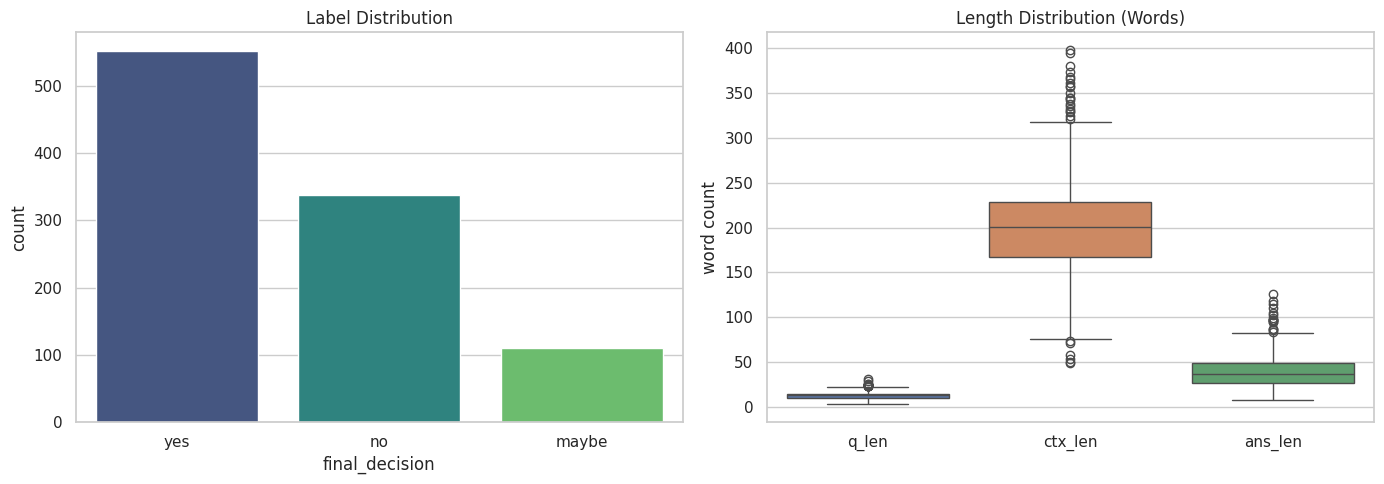

In [5]:
# Basic EDA: class distribution and text-length profile
df["q_len"] = df["QUESTION"].astype(str).apply(lambda x: len(x.split()))
df["ctx_len"] = df["CONTEXTS"].apply(lambda x: len(" ".join(x).split()) if isinstance(x, list) else len(str(x).split()))
df["ans_len"] = df["LONG_ANSWER"].astype(str).apply(lambda x: len(x.split()))

print("Class distribution:", df["final_decision"].value_counts().to_dict())
print("Average lengths:")
print(df[["q_len", "ctx_len", "ans_len"]].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="final_decision", order=LABEL_NAMES, ax=axes[0], hue="final_decision", palette="viridis", legend=False)
axes[0].set_title("Label Distribution")
axes[0].set_xlabel("final_decision")
axes[0].set_ylabel("count")

sns.boxplot(data=df[["q_len", "ctx_len", "ans_len"]], ax=axes[1])
axes[1].set_title("Length Distribution (Words)")
axes[1].set_ylabel("word count")

plt.tight_layout()
plt.show()

## 5. Prompt Formatting and Balanced Split

In [6]:
def tokenize_simple(text):
    text = re.sub(r"[^a-z0-9\s]", " ", str(text).lower())
    return [t for t in text.split() if len(t) > 2]

def compress_context(contexts, question, max_words=520, top_k=6):
    """Select most question-relevant context chunks by token overlap."""
    if isinstance(contexts, list):
        chunks = [str(c) for c in contexts if str(c).strip()]
    else:
        chunks = [str(contexts)]

    q_tokens = set(tokenize_simple(question))
    scored = []
    for chunk in chunks:
        c_tokens = set(tokenize_simple(chunk))
        overlap = len(q_tokens.intersection(c_tokens))
        scored.append((overlap, chunk))

    scored.sort(key=lambda x: x[0], reverse=True)
    selected = [x[1] for x in scored[:top_k]] if len(scored) > top_k else [x[1] for x in scored]
    merged = " ".join(selected)
    return " ".join(merged.split()[:max_words])

def format_train_prompt_reasoning(row):
    context_text = compress_context(row["CONTEXTS"], row["QUESTION"], max_words=520, top_k=6)
    question = str(row["QUESTION"]).strip()
    long_answer = str(row.get("LONG_ANSWER", "")).strip()
    decision = str(row["final_decision"]).strip().lower()

    if not long_answer:
        long_answer = "Evidence supports the final decision based on the provided biomedical context."

    return f"""### System:
You are a biomedical QA assistant. Read the context and answer the question.
Return concise reasoning then a final decision from this set: yes, no, maybe.

### Context:
{context_text}

### Question:
{question}

### Response:
Reasoning: {long_answer}
Final Decision: {decision}""".strip()

def format_train_prompt_decision_only(row):
    context_text = compress_context(row["CONTEXTS"], row["QUESTION"], max_words=520, top_k=6)
    question = str(row["QUESTION"]).strip()
    decision = str(row["final_decision"]).strip().lower()

    return f"""### System:
You are a biomedical QA assistant. Output only one label.
Valid labels: yes, no, maybe.

### Context:
{context_text}

### Question:
{question}

### Response:
Final Decision: {decision}""".strip()

def format_inference_prompt(row):
    context_text = compress_context(row["CONTEXTS"], row["QUESTION"], max_words=520, top_k=6)
    question = str(row["QUESTION"]).strip()
    return f"""### System:
You are a biomedical QA assistant.
Return exactly one line in this format: Final Decision: yes|no|maybe.

### Context:
{context_text}

### Question:
{question}

### Response:
Final Decision:""".strip()

In [7]:
train_df, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    stratify=df["final_decision"],
)

print("Original train distribution:", train_df["final_decision"].value_counts().to_dict())
print("Validation distribution:", val_df["final_decision"].value_counts().to_dict())

def oversample_train(input_df, label_col="final_decision", seed=42):
    counts = input_df[label_col].value_counts()
    target = counts.max()
    chunks = []
    for label in LABEL_NAMES:
        part = input_df[input_df[label_col] == label]
        sampled = part.sample(target, replace=True, random_state=seed)
        chunks.append(sampled)
    out = pd.concat(chunks).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return out

train_df_balanced = oversample_train(train_df, seed=SEED)
print("Balanced train distribution:", train_df_balanced["final_decision"].value_counts().to_dict())

# Dual-format supervision for better metric alignment
train_reasoning = train_df_balanced.copy()
train_reasoning["text"] = train_reasoning.apply(format_train_prompt_reasoning, axis=1)

train_decision = train_df_balanced.copy()
train_decision["text"] = train_decision.apply(format_train_prompt_decision_only, axis=1)

train_mixed = pd.concat([train_reasoning, train_decision], ignore_index=True).sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_df = val_df.copy()
val_df["text"] = val_df.apply(format_train_prompt_reasoning, axis=1)

dataset = DatasetDict({
    "train": Dataset.from_pandas(train_mixed[["text"]], preserve_index=False),
    "validation": Dataset.from_pandas(val_df[["text"]], preserve_index=False),
})

print(f"Train size (balanced + dual format): {len(dataset['train'])}")
print(f"Validation size: {len(dataset['validation'])}")

Original train distribution: {'yes': 497, 'no': 304, 'maybe': 99}
Validation distribution: {'yes': 55, 'no': 34, 'maybe': 11}
Balanced train distribution: {'no': 497, 'yes': 497, 'maybe': 497}
Train size (balanced + dual format): 2982
Validation size: 100


## 6. Unsloth QLoRA Setup and Model Loading

In [8]:
# Unsloth handles 4-bit loading internally when load_in_4bit=True.
# dtype=None lets Unsloth choose a suitable dtype for the current GPU.

dtype = None
load_in_4bit = True

def load_unsloth_model(model_name):
    """Load an Unsloth model with compatibility fallbacks for changing FastLanguageModel signatures."""
    common_kwargs = dict(
        model_name=model_name,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=dtype,
        load_in_4bit=load_in_4bit,
    )
    try:
        return FastLanguageModel.from_pretrained(
            **common_kwargs,
            trust_remote_code=True,
        )
    except TypeError as exc:
        # Some versions do not expose trust_remote_code in the wrapper.
        if "trust_remote_code" not in str(exc):
            raise
        return FastLanguageModel.from_pretrained(**common_kwargs)

try:
    model, tokenizer = load_unsloth_model(MODEL_NAME)
    active_model_name = MODEL_NAME
except Exception as exc:
    print(f"Primary Unsloth model load failed: {repr(exc)}")
    print(f"Falling back to: {FALLBACK_MODEL_NAME}")
    model, tokenizer = load_unsloth_model(FALLBACK_MODEL_NAME)
    active_model_name = FALLBACK_MODEL_NAME

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

print(f"Unsloth model and tokenizer ready: {active_model_name}")
print("Model dtype:", next(model.parameters()).dtype)
print("Model device:", next(model.parameters()).device)


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.6.8: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.55G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/605 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

unsloth/Qwen2.5-7B-Instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Unsloth model and tokenizer ready: unsloth/Qwen2.5-7B-Instruct-bnb-4bit
Model dtype: torch.float16
Model device: cuda:0


## 7. LoRA Adapters with Unsloth

In [9]:
peft_kwargs = dict(
    r=LORA_R,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
    use_rslora=False,
    loftq_config=None,
    max_seq_length=MAX_SEQ_LENGTH,
)

try:
    model = FastLanguageModel.get_peft_model(model, **peft_kwargs)
except TypeError as exc:
    # Older Unsloth versions may not accept every optional kwarg.
    print("Retrying get_peft_model with a reduced compatible argument set:", exc)
    peft_kwargs.pop("loftq_config", None)
    peft_kwargs.pop("max_seq_length", None)
    model = FastLanguageModel.get_peft_model(model, **peft_kwargs)

model.print_trainable_parameters()


Unsloth 2026.6.8 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


trainable params: 161,480,704 || all params: 7,777,097,216 || trainable%: 2.0764


## 8. Training Arguments

In [10]:
USE_BF16 = bool(torch.cuda.is_available() and is_bfloat16_supported())
USE_FP16 = bool(torch.cuda.is_available() and not USE_BF16)

def build_sft_config():
    """Create SFTConfig robustly across TRL versions.

    TRL has changed some names across releases:
    - `eval_strategy` vs `evaluation_strategy`
    - `max_seq_length` vs `max_length`
    - some versions include SFT fields in __init__, others only as attributes
    """
    sig = inspect.signature(SFTConfig.__init__)
    params = set(sig.parameters)

    kwargs = dict(
        output_dir=OUTPUT_DIR,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type="cosine",
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        optim="paged_adamw_8bit",
        fp16=USE_FP16,
        bf16=USE_BF16,
        gradient_checkpointing=True,
        max_grad_norm=0.3,
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=10,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to=[],
        dataloader_pin_memory=False,
        disable_tqdm=True,
        seed=SEED,
    )

    if "eval_strategy" in params:
        kwargs["eval_strategy"] = "epoch"
    elif "evaluation_strategy" in params:
        kwargs["evaluation_strategy"] = "epoch"

    # Add SFT fields only if the installed TRL exposes them in __init__.
    for key, value in {
        "dataset_text_field": "text",
        "max_seq_length": MAX_SEQ_LENGTH,
        "max_length": MAX_SEQ_LENGTH,
        "packing": False,
    }.items():
        if key in params:
            kwargs[key] = value

    # Drop kwargs not accepted by the current version. This handles older TrainingArguments variants.
    kwargs = {k: v for k, v in kwargs.items() if k in params}

    cfg = SFTConfig(**kwargs)

    # Also set as attributes for SFTTrainer versions that read them later.
    cfg.dataset_text_field = "text"
    cfg.max_seq_length = MAX_SEQ_LENGTH
    cfg.max_length = MAX_SEQ_LENGTH
    cfg.packing = False

    return cfg

training_args = build_sft_config()

print({
    "fp16": USE_FP16,
    "bf16": USE_BF16,
    "optim": getattr(training_args, "optim", None),
    "eval_strategy": getattr(training_args, "eval_strategy", getattr(training_args, "evaluation_strategy", None)),
    "max_seq_length": getattr(training_args, "max_seq_length", None),
    "max_length": getattr(training_args, "max_length", None),
    "dataset_text_field": getattr(training_args, "dataset_text_field", None),
    "packing": getattr(training_args, "packing", None),
    "report_to": getattr(training_args, "report_to", None),
})


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


{'fp16': True, 'bf16': False, 'optim': <OptimizerNames.PAGED_ADAMW_8BIT: 'paged_adamw_8bit'>, 'eval_strategy': <IntervalStrategy.EPOCH: 'epoch'>, 'max_seq_length': 1024, 'max_length': 1024, 'dataset_text_field': 'text', 'packing': False, 'report_to': []}


## 9. Evaluation Helpers (Strict Decision Extraction)

In [11]:
decision_pattern = re.compile(r"final\s*decision\s*:\s*(yes|no|maybe)", re.IGNORECASE)

def extract_decision(text):
    match = decision_pattern.search(str(text))
    if match:
        return match.group(1).lower()
    return "unknown"

def get_model_device(model):
    return next(model.parameters()).device

@torch.no_grad()
def candidate_logprob(model, tokenizer, prompt, candidate):
    """Compute normalized conditional log-probability for candidate label."""
    device = get_model_device(model)
    full_text = prompt + " " + candidate
    enc_full = tokenizer(full_text, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(device)
    enc_prompt = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=MAX_SEQ_LENGTH).to(device)

    input_ids = enc_full["input_ids"]
    attention_mask = enc_full["attention_mask"]
    prompt_len = enc_prompt["input_ids"].shape[1]

    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits[:, :-1, :]
    labels = input_ids[:, 1:]

    log_probs = torch.log_softmax(logits, dim=-1)
    token_log_probs = log_probs.gather(dim=-1, index=labels.unsqueeze(-1)).squeeze(-1)

    start = max(prompt_len - 1, 0)
    cand_token_log_probs = token_log_probs[:, start:]
    if cand_token_log_probs.numel() == 0:
        return -1e9

    return cand_token_log_probs.mean().item()

@torch.no_grad()
def predict_validation(model, tokenizer, frame, max_samples=None):
    model.eval()
    preds, trues = [], []

    n = len(frame) if max_samples is None else min(len(frame), max_samples)
    candidates = ["yes", "no", "maybe"]

    for idx in range(n):
        row = frame.iloc[idx]
        base_prompt = format_inference_prompt(row)

        scores = {cand: candidate_logprob(model, tokenizer, base_prompt, cand) for cand in candidates}
        pred = max(scores, key=scores.get)
        true_label = str(row["final_decision"]).lower()

        preds.append(pred if pred in LABEL_SET else "unknown")
        trues.append(true_label)

        if torch.cuda.is_available() and idx % 25 == 0:
            torch.cuda.empty_cache()

    return preds, trues


## 10. Initialize Trainer and Train

In [12]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

trainer_kwargs = dict(
    model=model,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    args=training_args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer_signature = inspect.signature(SFTTrainer.__init__).parameters
if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_signature:
    trainer_kwargs["tokenizer"] = tokenizer
else:
    print("Warning: SFTTrainer signature has neither `processing_class` nor `tokenizer`; continuing without tokenizer argument.")

try:
    trainer = SFTTrainer(**trainer_kwargs)
except TypeError as exc:
    # Last-resort compatibility retry for TRL versions with different tokenizer argument names.
    print("Initial SFTTrainer init failed:", exc)
    trainer_kwargs.pop("processing_class", None)
    trainer_kwargs.pop("tokenizer", None)
    trainer_kwargs["tokenizer"] = tokenizer
    trainer = SFTTrainer(**trainer_kwargs)

# Transformers 5.x can attach NotebookProgressCallback in notebook environments.
# In this setup it can raise:
#   RuntimeError: on_train_begin must be called before on_evaluate
# during a manual trainer.evaluate() call after training. We remove it and keep normal logging.
def remove_notebook_progress_callback(trainer):
    removed = []
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        try:
            trainer.remove_callback(NotebookProgressCallback)
            removed.append("NotebookProgressCallback")
        except Exception:
            pass
    except Exception:
        pass

    # Defensive cleanup by class name for version differences.
    try:
        kept_callbacks = []
        for cb in trainer.callback_handler.callbacks:
            if cb.__class__.__name__ == "NotebookProgressCallback":
                removed.append(cb.__class__.__name__)
            else:
                kept_callbacks.append(cb)
        trainer.callback_handler.callbacks = kept_callbacks
    except Exception as exc:
        print("Callback cleanup warning:", repr(exc))

    if removed:
        print("Removed callbacks:", sorted(set(removed)))

remove_notebook_progress_callback(trainer)

print("Unsloth SFTTrainer initialized")
print("Trainer class:", type(trainer).__name__)
print("Callbacks:", [cb.__class__.__name__ for cb in trainer.callback_handler.callbacks])


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/2982 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/100 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Removed callbacks: ['NotebookProgressCallback']
Unsloth SFTTrainer initialized
Trainer class: UnslothSFTTrainer
Callbacks: ['DefaultFlowCallback', 'EarlyStoppingCallback', 'PrinterCallback']


In [13]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print(f"Training started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
train_start = time.time()
train_result = trainer.train()
train_runtime_seconds = time.time() - train_start
print(f"Training completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

peak_memory_gb = None
if torch.cuda.is_available():
    peak_memory_gb = torch.cuda.max_memory_reserved() / 1024**3
    print(f"Peak reserved GPU memory: {peak_memory_gb:.2f} GB")

print(f"Wall-clock train runtime: {train_runtime_seconds:.2f} seconds")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Training started: 2026-06-20 04:04:13


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,982 | Num Epochs = 3 | Total steps = 561
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 16 x 1) = 16
 "-____-"     Trainable parameters = 161,480,704 of 7,777,097,216 (2.08% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
{'loss': '2.085', 'grad_norm': '0.8355', 'learning_rate': '3.176e-05', 'epoch': '0.05366'}
{'loss': '1.604', 'grad_norm': '0.3416', 'learning_rate': '6.706e-05', 'epoch': '0.1073'}
{'loss': '1.488', 'grad_norm': '0.359', 'learning_rate': '0.0001024', 'epoch': '0.161'}
{'loss': '1.444', 'grad_norm': '0.3742', 'learning_rate': '0.00012', 'epoch': '0.2146'}
{'loss': '1.389', 'grad_norm': '0.5446', 'learning_rate': '0.0001198', 'epoch': '0.2683'}
{'loss': '1.305', 'grad_norm': '0.5434', 'learning_rate': '0.0001193', 'epoch': '0.3219'}
{'loss': '1.192', 'grad_norm': '0.6432', 'learning_rate': '0.0001187', 'epoch': '0.3756'}
{'loss': '1.165', 'grad_norm': '0.7942', 'learning_rate': '0.0001179', 'epoch': '0.4292'}
{'loss': '1.025', 'grad_norm': '1.341', 'learning_rate': '0.0001168', 'epoch': '0.4829'}
{'loss': '0.9842', 'grad_norm': '0.9398', 'learning_rate': '0.

Unsloth: Restored added_tokens_decoder metadata in ./results_qwen_pubmed_unsloth/checkpoint-187/tokenizer_config.json.


{'loss': '0.5694', 'grad_norm': '1.046', 'learning_rate': '9.616e-05', 'epoch': '1.016'}
{'loss': '0.3495', 'grad_norm': '0.8204', 'learning_rate': '9.324e-05', 'epoch': '1.07'}
{'loss': '0.4106', 'grad_norm': '0.9081', 'learning_rate': '9.021e-05', 'epoch': '1.123'}
{'loss': '0.2838', 'grad_norm': '0.9837', 'learning_rate': '8.706e-05', 'epoch': '1.177'}
{'loss': '0.3279', 'grad_norm': '0.8573', 'learning_rate': '8.383e-05', 'epoch': '1.231'}
{'loss': '0.2606', 'grad_norm': '0.8002', 'learning_rate': '8.05e-05', 'epoch': '1.284'}
{'loss': '0.3206', 'grad_norm': '0.8753', 'learning_rate': '7.711e-05', 'epoch': '1.338'}
{'loss': '0.3246', 'grad_norm': '0.7827', 'learning_rate': '7.365e-05', 'epoch': '1.392'}
{'loss': '0.3015', 'grad_norm': '1.3', 'learning_rate': '7.014e-05', 'epoch': '1.445'}
{'loss': '0.2721', 'grad_norm': '1.195', 'learning_rate': '6.66e-05', 'epoch': '1.499'}
{'loss': '0.2461', 'grad_norm': '0.7897', 'learning_rate': '6.304e-05', 'epoch': '1.553'}
{'loss': '0.2356',

Unsloth: Restored added_tokens_decoder metadata in ./results_qwen_pubmed_unsloth/checkpoint-374/tokenizer_config.json.


{'loss': '0.1132', 'grad_norm': '0.3532', 'learning_rate': '3.198e-05', 'epoch': '2.032'}
{'loss': '0.08771', 'grad_norm': '0.7396', 'learning_rate': '2.887e-05', 'epoch': '2.086'}
{'loss': '0.09779', 'grad_norm': '0.699', 'learning_rate': '2.587e-05', 'epoch': '2.14'}
{'loss': '0.0761', 'grad_norm': '0.5706', 'learning_rate': '2.299e-05', 'epoch': '2.193'}
{'loss': '0.08983', 'grad_norm': '0.7268', 'learning_rate': '2.024e-05', 'epoch': '2.247'}
{'loss': '0.098', 'grad_norm': '0.5455', 'learning_rate': '1.764e-05', 'epoch': '2.3'}
{'loss': '0.08435', 'grad_norm': '0.5794', 'learning_rate': '1.518e-05', 'epoch': '2.354'}
{'loss': '0.06372', 'grad_norm': '0.8321', 'learning_rate': '1.288e-05', 'epoch': '2.408'}
{'loss': '0.08901', 'grad_norm': '0.4448', 'learning_rate': '1.075e-05', 'epoch': '2.461'}
{'loss': '0.08456', 'grad_norm': '0.5736', 'learning_rate': '8.8e-06', 'epoch': '2.515'}
{'loss': '0.0635', 'grad_norm': '0.5224', 'learning_rate': '7.027e-06', 'epoch': '2.569'}
{'loss': '

Unsloth: Restored added_tokens_decoder metadata in ./results_qwen_pubmed_unsloth/checkpoint-561/tokenizer_config.json.


{'train_runtime': '1.456e+04', 'train_samples_per_second': '0.614', 'train_steps_per_second': '0.039', 'train_loss': '0.4675', 'epoch': '3'}
Training completed: 2026-06-20 08:06:56
Peak reserved GPU memory: 7.88 GB
Wall-clock train runtime: 14563.01 seconds


In [14]:
print(f"Global steps: {train_result.global_step}")
print(f"Train loss: {train_result.training_loss:.4f}")
print(f"Best checkpoint: {trainer.state.best_model_checkpoint}")

train_metrics = dict(getattr(train_result, "metrics", {}) or {})
train_metrics["wall_clock_train_runtime_seconds"] = train_runtime_seconds
train_metrics["peak_reserved_gpu_memory_gb"] = peak_memory_gb
print("Train metrics:")
for k, v in train_metrics.items():
    print(f"{k}: {v}")


Global steps: 561
Train loss: 0.4675
Best checkpoint: ./results_qwen_pubmed_unsloth/checkpoint-187
Train metrics:
train_runtime: 14560.6775
train_samples_per_second: 0.614
train_steps_per_second: 0.039
train_loss: 0.46747227608095093
epoch: 3.0
wall_clock_train_runtime_seconds: 14563.008769750595
peak_reserved_gpu_memory_gb: 7.884765625


## 11. Validation Metrics and Inference-Based Evaluation

In [15]:
# Loss-based eval from trainer
# Remove notebook-only progress callback again before manual evaluation.
# This avoids Transformers notebook callback state errors in some 5.x notebook runtimes.
try:
    remove_notebook_progress_callback(trainer)
except NameError:
    pass

try:
    eval_results = trainer.evaluate()
except RuntimeError as exc:
    if "on_train_begin must be called before on_evaluate" in str(exc):
        print("Notebook progress callback state bug detected during evaluate(). Retrying with callbacks cleaned.")
        try:
            trainer.callback_handler.callbacks = [
                cb for cb in trainer.callback_handler.callbacks
                if cb.__class__.__name__ != "NotebookProgressCallback"
            ]
        except Exception:
            pass
        eval_results = trainer.evaluate()
    else:
        raise

print("Trainer eval:")
for k, v in eval_results.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")
    else:
        print(f"{k}: {v}")


Removed callbacks: ['NotebookProgressCallback']
{'eval_loss': '1.748', 'eval_runtime': '58.48', 'eval_samples_per_second': '1.71', 'eval_steps_per_second': '1.71', 'epoch': '3'}
Trainer eval:
eval_loss: 1.7482
eval_runtime: 58.4805
eval_samples_per_second: 1.7100
eval_steps_per_second: 1.7100
epoch: 3.0000


## 12. Deterministic Classification Evaluation (Accuracy/F1)

In [16]:
# Switch to Unsloth's optimized inference mode before log-probability evaluation.
FastLanguageModel.for_inference(trainer.model)

all_predictions, all_true_labels = predict_validation(
    trainer.model,
    tokenizer,
    val_df.reset_index(drop=True),
    max_samples=EVAL_MAX_SAMPLES,
)

valid_pairs = [
    (p, t) for p, t in zip(all_predictions, all_true_labels)
    if p in LABEL_SET and t in LABEL_SET
]

if len(valid_pairs) == 0:
    raise RuntimeError("No valid predictions extracted. Check prompt/output format.")

predictions, true_labels = zip(*valid_pairs)
predictions, true_labels = list(predictions), list(true_labels)

print(f"Total samples evaluated: {len(all_true_labels)}")
print(f"Valid extracted predictions: {len(predictions)}")
print(f"Unknown/invalid predictions: {len(all_true_labels) - len(predictions)}")


Total samples evaluated: 100
Valid extracted predictions: 100
Unknown/invalid predictions: 0


In [17]:
final_accuracy = accuracy_score(true_labels, predictions)
final_f1_macro = f1_score(true_labels, predictions, average="macro", labels=LABEL_NAMES, zero_division=0)
final_f1_weighted = f1_score(true_labels, predictions, average="weighted", labels=LABEL_NAMES, zero_division=0)

print("Final decision metrics")
print("=" * 50)
print(f"Accuracy: {final_accuracy:.4f} ({final_accuracy * 100:.2f}%)")
print(f"F1 Macro: {final_f1_macro:.4f}")
print(f"F1 Weighted: {final_f1_weighted:.4f}")
print("=" * 50)

print("\nClassification report:")
print(classification_report(true_labels, predictions, labels=LABEL_NAMES, zero_division=0))

Final decision metrics
Accuracy: 0.7800 (78.00%)
F1 Macro: 0.5498
F1 Weighted: 0.7346

Classification report:
              precision    recall  f1-score   support

         yes       0.79      0.87      0.83        55
          no       0.77      0.88      0.82        34
       maybe       0.00      0.00      0.00        11

    accuracy                           0.78       100
   macro avg       0.52      0.59      0.55       100
weighted avg       0.69      0.78      0.73       100



## 13. Results EDA: Confusion Matrix, Error Profile, Training Curves

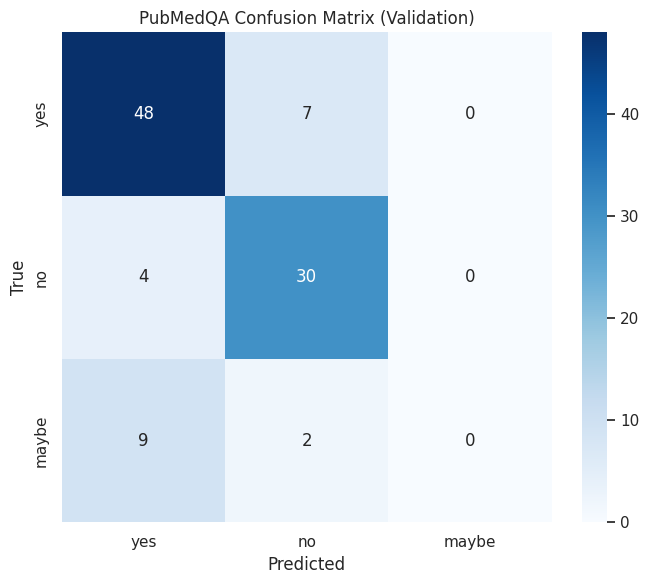

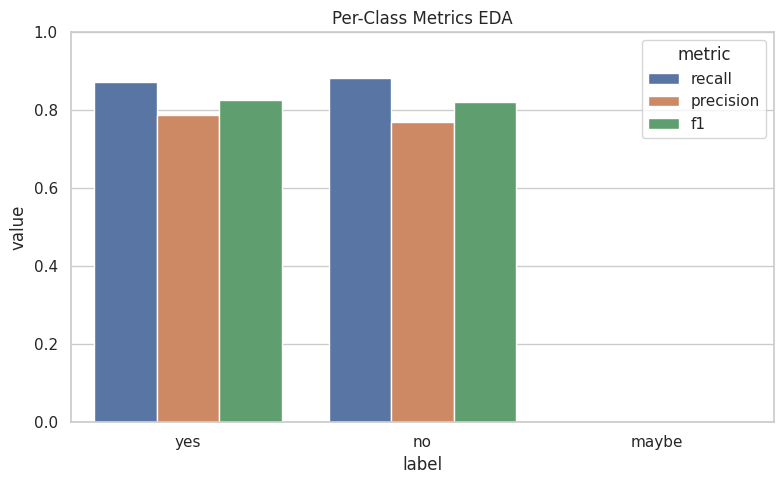

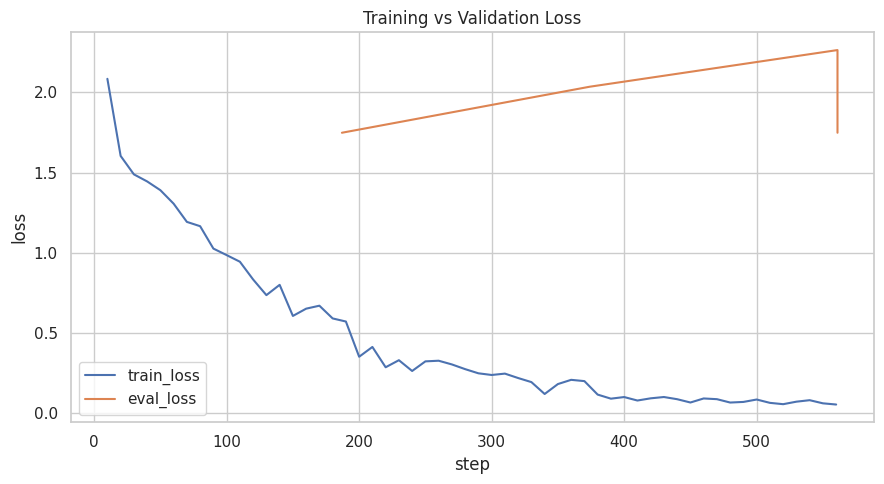

Saved prediction analysis to ./results_qwen_pubmed_unsloth/validation_predictions.csv


In [18]:
# 1) Confusion matrix
cm = confusion_matrix(true_labels, predictions, labels=LABEL_NAMES)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
 )
plt.title("PubMedQA Confusion Matrix (Validation)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150)
plt.show()

# 2) Per-class metrics EDA
class_report = classification_report(
    true_labels,
    predictions,
    labels=LABEL_NAMES,
    output_dict=True,
    zero_division=0,
 )
recall_frame = pd.DataFrame({
    "label": LABEL_NAMES,
    "recall": [class_report[label]["recall"] for label in LABEL_NAMES],
    "precision": [class_report[label]["precision"] for label in LABEL_NAMES],
    "f1": [class_report[label]["f1-score"] for label in LABEL_NAMES],
})

plt.figure(figsize=(8, 5))
sns.barplot(
    data=recall_frame.melt(id_vars="label", var_name="metric", value_name="value"),
    x="label",
    y="value",
    hue="metric",
)
plt.ylim(0, 1)
plt.title("Per-Class Metrics EDA")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/per_class_metrics.png", dpi=150)
plt.show()

# 3) Training dynamics EDA from trainer log history
log_df = pd.DataFrame(trainer.state.log_history)
train_log = log_df.dropna(subset=["loss", "step"])[["step", "loss"]].copy()
eval_log = log_df.dropna(subset=["eval_loss", "step"])[["step", "eval_loss"]].copy()

if len(train_log) > 0 or len(eval_log) > 0:
    plt.figure(figsize=(9, 5))
    if len(train_log) > 0:
        plt.plot(train_log["step"], train_log["loss"], label="train_loss")
    if len(eval_log) > 0:
        plt.plot(eval_log["step"], eval_log["eval_loss"], label="eval_loss")
    plt.title("Training vs Validation Loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/loss_curves.png", dpi=150)
    plt.show()

# 4) Save row-level predictions for error analysis
pred_frame = val_df.reset_index(drop=True).copy()
pred_frame["predicted"] = all_predictions
pred_frame["is_valid_prediction"] = pred_frame["predicted"].isin(LABEL_NAMES)
pred_frame["is_correct"] = pred_frame.apply(
    lambda r: (str(r["final_decision"]).lower() == str(r["predicted"]).lower()) if r["is_valid_prediction"] else False,
    axis=1,
)
pred_frame.to_csv(f"{OUTPUT_DIR}/validation_predictions.csv", index=False)
print(f"Saved prediction analysis to {OUTPUT_DIR}/validation_predictions.csv")

## 14. Save Fine-Tuned Model and Run Summary

In [19]:
save_path = f"{OUTPUT_DIR}/{NEW_MODEL_NAME}"

# Save LoRA adapter + tokenizer. This is the lightest and best default for comparing runs.
trainer.model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

# Optional exports. Keep False during experiments to save time and disk.
SAVE_MERGED_16BIT = False
SAVE_GGUF_Q8_0 = False

if SAVE_MERGED_16BIT:
    merged_path = f"{OUTPUT_DIR}/{NEW_MODEL_NAME}-merged-16bit"
    trainer.model.save_pretrained_merged(
        merged_path,
        tokenizer,
        save_method="merged_16bit",
    )
    print(f"Merged 16-bit model saved to: {merged_path}")

if SAVE_GGUF_Q8_0:
    gguf_path = f"{OUTPUT_DIR}/{NEW_MODEL_NAME}-gguf"
    trainer.model.save_pretrained_gguf(
        gguf_path,
        tokenizer,
        quantization_method="q8_0",
    )
    print(f"GGUF model saved to: {gguf_path}")

summary_df = pd.DataFrame([
    {
        "framework": "unsloth",
        "active_model": active_model_name,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "effective_batch_size": BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS,
        "learning_rate": LEARNING_RATE,
        "max_seq_length": MAX_SEQ_LENGTH,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "lora_dropout": LORA_DROPOUT,
        "accuracy": final_accuracy,
        "f1_macro": final_f1_macro,
        "f1_weighted": final_f1_weighted,
        "best_checkpoint": str(trainer.state.best_model_checkpoint),
        "trainer_train_runtime": train_metrics.get("train_runtime"),
        "wall_clock_train_runtime_seconds": train_metrics.get("wall_clock_train_runtime_seconds"),
        "train_samples_per_second": train_metrics.get("train_samples_per_second"),
        "train_steps_per_second": train_metrics.get("train_steps_per_second"),
        "peak_reserved_gpu_memory_gb": train_metrics.get("peak_reserved_gpu_memory_gb"),
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
    }
])
summary_df.to_csv(f"{OUTPUT_DIR}/run_summary.csv", index=False)

print(f"LoRA adapter saved to: {save_path}")
print(f"Summary saved to: {OUTPUT_DIR}/run_summary.csv")
display(summary_df)
print("Unsloth notebook pipeline completed.")


Unsloth: Restored added_tokens_decoder metadata in ./results_qwen_pubmed_unsloth/Qwen2.5-7B-PubMedQA-Unsloth-QLoRA/tokenizer_config.json.


LoRA adapter saved to: ./results_qwen_pubmed_unsloth/Qwen2.5-7B-PubMedQA-Unsloth-QLoRA
Summary saved to: ./results_qwen_pubmed_unsloth/run_summary.csv


,framework,active_model,epochs,batch_size,gradient_accumulation_steps,effective_batch_size,learning_rate,max_seq_length,lora_r,lora_alpha,...,f1_macro,f1_weighted,best_checkpoint,trainer_train_runtime,wall_clock_train_runtime_seconds,train_samples_per_second,train_steps_per_second,peak_reserved_gpu_memory_gb,torch_version,cuda_available
0,unsloth,unsloth/Qwen2.5-7B-Instruct-bnb-4bit,3,1,16,16,0.00012,1024,64,128,...,0.549835,0.734624,./results_qwen_pubmed_unsloth/checkpoint-187,14560.6775,14563.00877,0.614,0.039,7.884766,2.10.0+cu128,True


Unsloth notebook pipeline completed.


## 15. How to Compare with the Original Notebook

After running both notebooks under the same GPU/runtime, compare:

1. `accuracy`, `f1_macro`, `f1_weighted`
2. `trainer_train_runtime` or `wall_clock_train_runtime_seconds`
3. `train_samples_per_second` and `train_steps_per_second`
4. `peak_reserved_gpu_memory_gb`
5. Confusion matrix and per-class metrics

Both notebooks save:
- `run_summary.csv`
- `validation_predictions.csv`
- `confusion_matrix.png`
- `per_class_metrics.png`
- `loss_curves.png`

Suggested interpretation:
- If metrics are similar but runtime/memory improves, Unsloth is useful for this setup.
- If metrics change a lot, re-run with `LORA_DROPOUT = 0.05` for stricter comparison to the original notebook.
- If fallback model is used, do **not** compare accuracy directly because the model size changed.
